# Model Team A – Interpretable Baseline

This notebook implements the **Model Team A** workflow for recession forecasting using the uploaded transformed quarterly dataset:

1. Logistic regression baselines for **1Q, 2Q, 3Q ahead**
2. Feature engineering with **lags, rolling averages, and regime dummies**
3. **Mutual information** ranking
4. **L1-regularized logistic regression** for sparse feature selection
5. **Walk-forward validation** with expanding windows
6. ROC, calibration, and probability path plots
7. Coefficient significance tables (descriptive, via `statsmodels`)

The implementation follows the project brief for Model Team A and uses the transformed post-1986 dataset prepared by the data team.


# 1 - Load Libraries - Environment Setup

In [14]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, log_loss, roc_curve
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")


# 2 - Data Ingestion & Preprocessing

## 2.1 - load the data

In [15]:
DATA_PATH = "DS_SOURCES_PIPELINE/master_dataset_transformed_after_1986.csv"
OUTDIR = "model_team_a_outputs"
os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Date,USRECD,T10Y2Y,TEDRATE,BAA10Y,Target_1Q_ahead,Target_2Q_ahead,Target_3Q_ahead,BAA10Y_missing,T10Y2Y_missing,FEDFUNDS_missing,UNRATE_d1,INDPRO_lgyoy,CPIAUCSL_lgyoy,FEDFUNDS_d1
0,1986-01-01,0.0,0.789333,1.012034,2.452667,0.0,0.0,0.0,0,0,0,0.000000,0.010821,0.030582,-0.276667
1,1986-04-01,0.0,0.620156,0.859048,2.672656,0.0,0.0,0.0,0,0,0,0.133333,0.004214,0.016647,-0.906667
2,1986-07-01,0.0,0.855781,0.766984,2.877031,0.0,0.0,0.0,0,0,0,-0.200000,0.009566,0.016544,-0.713333
3,1986-10-01,0.0,0.988226,0.808197,2.828065,0.0,0.0,0.0,0,0,0,-0.133333,0.015031,0.013366,0.060000
4,1987-01-01,0.0,0.844262,0.847705,2.466393,0.0,0.0,0.0,0,0,0,-0.233333,0.022378,0.020178,-0.046667


## 2.2 - Data Cleaning (Handling Unreliable Features: "TEDRATE")

In [16]:
df = df.drop(columns= ["BAA10Y_missing", "T10Y2Y_missing", "FEDFUNDS_missing","TEDRATE"])
df.head()

,Date,USRECD,T10Y2Y,BAA10Y,Target_1Q_ahead,Target_2Q_ahead,Target_3Q_ahead,UNRATE_d1,INDPRO_lgyoy,CPIAUCSL_lgyoy,FEDFUNDS_d1
0,1986-01-01,0.0,0.789333,2.452667,0.0,0.0,0.0,0.000000,0.010821,0.030582,-0.276667
1,1986-04-01,0.0,0.620156,2.672656,0.0,0.0,0.0,0.133333,0.004214,0.016647,-0.906667
2,1986-07-01,0.0,0.855781,2.877031,0.0,0.0,0.0,-0.200000,0.009566,0.016544,-0.713333
3,1986-10-01,0.0,0.988226,2.828065,0.0,0.0,0.0,-0.133333,0.015031,0.013366,0.060000
4,1987-01-01,0.0,0.844262,2.466393,0.0,0.0,0.0,-0.233333,0.022378,0.020178,-0.046667


## 2.3 - Feature Engineering: Temporal Dynamics & Regime Shifts

In [17]:
# Feature engineering
signal_cols = [
    "T10Y2Y",  "BAA10Y",
    "UNRATE_d1", "INDPRO_lgyoy", "CPIAUCSL_lgyoy", "FEDFUNDS_d1"
]

edf = df.copy()

for col in signal_cols:
    for lag in [1, 2, 3]:
        edf[f"{col}_lag{lag}"] = edf[col].shift(lag)
    for win in [3, 6]:
        edf[f"{col}_roll{win}"] = edf[col].rolling(win, min_periods=win).mean()

edf["post_2008"] = (edf["Date"] >= pd.Timestamp("2008-01-01")).astype(int)
edf["post_2020"] = (edf["Date"] >= pd.Timestamp("2020-01-01")).astype(int)

target_cols = ["Target_1Q_ahead", "Target_2Q_ahead", "Target_3Q_ahead"]
feature_cols = [c for c in edf.columns if c not in ["Date", "USRECD"] + target_cols]

print("Rows:", len(edf))
print("Engineered features:", len(feature_cols))
print(feature_cols[:10])


Rows: 145
Engineered features: 38
['T10Y2Y', 'BAA10Y', 'UNRATE_d1', 'INDPRO_lgyoy', 'CPIAUCSL_lgyoy', 'FEDFUNDS_d1', 'T10Y2Y_lag1', 'T10Y2Y_lag2', 'T10Y2Y_lag3', 'T10Y2Y_roll3']


# 3 - Baseline Modeling Strategy

## 3.1 - Core Functions & Feature Selection (Mutual Information)

**Validation Strategy & Model Dynamics**

**1. Expanding vs. Rolling Window Validation**
* **Expanding Window:** Incrementally includes new data while retaining all historical observations. This is the preferred approach for our dataset; since recessions are rare events, retaining the full history ensures the model does not "forget" past recession patterns.
* **Rolling Window:** Maintains a fixed training size by continuously dropping the oldest data. While useful for adapting to structural regime shifts, it risks discarding critical minority-class examples (historical recessions) once they fall outside the training window. 

**2. Target Autocorrelation & Model "Statelessness"**
* Standard algorithms like Logistic Regression are inherently *stateless*—they evaluate each time step ($t$) independently without explicitly learning temporal sequences.
* The model outputs consecutive recession predictions not because it "remembers" the previous quarter, but because the macroeconomic input features ($X$) are highly autocorrelated. The persistence of poor economic conditions naturally leads to persistent predictions.
* To explicitly capture state dependence, specific feature engineering (e.g., including lagged target variables) would be required.

**3. Multi-Quarter Horizons as a Natural Embargo**
* Predicting extended horizons (such as 2Q or 3Q ahead) acts as a built-in "embargo" mechanism. By shifting the target variable forward, a natural temporal gap is created between the observed features and the predicted event. 
* This buffer helps mitigate immediate serial correlation and prevents short-term data leakage, forcing the model to rely on genuine leading indicators rather than overlapping, short-term macroeconomic momentum.

Hardcoded Values: Values like initial=60, test=8, step=8 in expanding_splits are hardcoded without explanation.

In [18]:

def prep_dataset(horizon: str):
    data = edf.dropna(subset=feature_cols + [horizon]).copy().reset_index(drop=True)
    X = data[feature_cols]
    y = data[horizon].astype(int)
    return data, X, y

def expanding_splits(n: int, initial: int = 60, test: int = 8, step: int = 8):
    splits = []
    start = initial
    while start + test <= n:
        splits.append((np.arange(start), np.arange(start, start + test)))
        start += step
    return splits


In [19]:
# ==========================================
# Initialization & Feature Selection
# ==========================================
horizons = ["Target_1Q_ahead", "Target_2Q_ahead", "Target_3Q_ahead"]

# Global dictionaries to store outputs across cells
all_results = []
mi_tables = {}
coef_tables = {}
oof_store = {}

for horizon in horizons:
    data, X, y = prep_dataset(horizon)
    
    # Descriptive MI ranking on the full sample
    imp = SimpleImputer(strategy="median")
    X_imp = imp.fit_transform(X)
    
    # Identify discrete features for MI calculation
    discrete_mask = [c.endswith("_missing") or c.startswith("post_") for c in feature_cols]
    
    mi = mutual_info_classif(X_imp, y, discrete_features=discrete_mask, n_neighbors=3, random_state=42)
    mi_tables[horizon] = pd.Series(mi, index=feature_cols).sort_values(ascending=False).head(15)

# Example output: Show the top 10 features for the 1Q horizon
print("Top features for 1Q Ahead based on Mutual Information:")
display(mi_tables["Target_1Q_ahead"].head(10))

Top features for 1Q Ahead based on Mutual Information:


UNRATE_d1               0.127216
FEDFUNDS_d1_roll3       0.124906
UNRATE_d1_roll3         0.108188
UNRATE_d1_roll6         0.102111
T10Y2Y_lag3             0.084538
FEDFUNDS_d1             0.072426
FEDFUNDS_d1_lag1        0.071572
INDPRO_lgyoy_roll6      0.070888
CPIAUCSL_lgyoy_roll6    0.060085
UNRATE_d1_lag1          0.060043
dtype: float64

## 3.2 - Model Training via Walk-Forward Validation

In [20]:
# ==========================================
# Walk-Forward Validation Pipeline
# ==========================================
for horizon in horizons:
    print(f"Training models for {horizon}...")
    data, X, y = prep_dataset(horizon)
    splits = expanding_splits(len(data), initial=60, test=8, step=8)

    models = {
        "full_l2": LogisticRegression(
            penalty="l2", C=1.0, class_weight="balanced",
            max_iter=5000, solver="liblinear"
        ),
        "sparse_l1": LogisticRegression(
            penalty="l1", C=0.25, class_weight="balanced",
            max_iter=5000, solver="liblinear"
        ),
    }

    for model_name, model in models.items():
        preds, ys, dates = [], [], []

        for tr, te in splits:
            Xtr, Xte = X.iloc[tr], X.iloc[te]
            ytr, yte = y.iloc[tr], y.iloc[te]

            # Prevent data leakage: Fit imputers and scalers ONLY on training data
            imp = SimpleImputer(strategy="median")
            scaler = StandardScaler()

            Xtr_s = scaler.fit_transform(imp.fit_transform(Xtr))
            Xte_s = scaler.transform(imp.transform(Xte))

            # Train and predict
            model.fit(Xtr_s, ytr)
            p = model.predict_proba(Xte_s)[:, 1]

            preds.extend(p)
            ys.extend(yte.tolist())
            dates.extend(data.iloc[te]["Date"].tolist())

        # Store Out-Of-Fold (OOF) predictions and calculate metrics
        ys = np.array(ys)
        preds = np.array(preds)

        all_results.append({
            "horizon": horizon.replace("Target_", "").replace("_ahead", ""),
            "model": model_name,
            "oof_n": len(ys),
            "positives": int(ys.sum()),
            "auc": roc_auc_score(ys, preds),
            "average_precision": average_precision_score(ys, preds),
            "brier": brier_score_loss(ys, preds),
            "log_loss": log_loss(ys, preds, labels=[0, 1]),
        })

        oof_store[(horizon, model_name)] = pd.DataFrame({
            "Date": pd.to_datetime(dates),
            "y_true": ys,
            "y_prob": preds
        }).sort_values("Date")
        
print("Walk-Forward Validation completed successfully!")

Training models for Target_1Q_ahead...
Training models for Target_2Q_ahead...
Training models for Target_3Q_ahead...
Walk-Forward Validation completed successfully!


## 3.3 - Evaluation Metrics & Statistical Inference

In [21]:
# ==========================================
# Performance Metrics Summary
# ==========================================
results_df = pd.DataFrame(all_results).sort_values(["model", "horizon"])

print("Out-of-Sample Performance Metrics:")
display(results_df)

Out-of-Sample Performance Metrics:


,horizon,model,oof_n,positives,auc,average_precision,brier,log_loss
0,1Q,full_l2,80,8,0.925347,0.423531,0.098081,1.004741
2,2Q,full_l2,80,8,0.835069,0.444292,0.121492,0.504230
4,3Q,full_l2,80,8,0.743056,0.223506,0.200465,0.857296
1,1Q,sparse_l1,80,8,0.953125,0.628206,0.075508,0.573895
3,2Q,sparse_l1,80,8,0.921875,0.542883,0.095773,0.322903
5,3Q,sparse_l1,80,8,0.850694,0.368340,0.134199,0.406158


In [22]:
# ==========================================
# Statistical Significance (Statsmodels)
# ==========================================
import statsmodels.api as sm

for horizon in horizons:
    data, X, y = prep_dataset(horizon)

    imp = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    Xs = scaler.fit_transform(imp.fit_transform(X))

    # Fit L1 Logistic Regression to extract non-zero features
    l1 = LogisticRegression(
        penalty="l1", C=0.25, class_weight="balanced",
        max_iter=5000, solver="liblinear"
    )
    l1.fit(Xs, y)

    nz_idx = [i for i, v in enumerate(l1.coef_[0]) if abs(v) > 1e-9]
    if len(nz_idx) == 0:
        nz_idx = np.argsort(np.abs(l1.coef_[0]))[::-1][:5].tolist()

    Xsel = pd.DataFrame(Xs[:, nz_idx], columns=[feature_cols[i] for i in nz_idx])
    Xsm = sm.add_constant(Xsel, has_constant="add")

    try:
        fit = sm.Logit(y, Xsm).fit(disp=False)
        conf = fit.conf_int()
        coef_tables[horizon] = pd.DataFrame({
            "feature": fit.params.index,
            "coef": fit.params.values,
            "p_value": fit.pvalues.values,
            "odds_ratio": np.exp(fit.params.values),
            "ci_low": np.exp(conf[0].values),
            "ci_high": np.exp(conf[1].values),
        }).sort_values("p_value")
    except Exception:
        coef_tables[horizon] = pd.DataFrame({
            "feature": ["model_failed"],
            "coef": [np.nan],
            "p_value": [np.nan],
            "odds_ratio": [np.nan],
            "ci_low": [np.nan],
            "ci_high": [np.nan],
        })

# Example output: Display significance table for 1Q Ahead
print("Statistical Inference (p-values & Odds Ratios) for 1Q Ahead:")
display(coef_tables["Target_1Q_ahead"])

Statistical Inference (p-values & Odds Ratios) for 1Q Ahead:


,feature,coef,p_value,odds_ratio,ci_low,ci_high
0,const,-19.255922,0.041389,4.337696e-09,3.991160e-17,4.714321e-01
3,CPIAUCSL_lgyoy,3.684554,0.045584,3.982736e+01,1.075041e+00,1.475496e+03
9,FEDFUNDS_d1_lag3,-2.872365,0.074736,5.656501e-02,2.402017e-03,1.332047e+00
1,BAA10Y,5.913129,0.094252,3.698615e+02,3.632478e-01,3.765956e+05
11,post_2008,3.671164,0.100019,3.929761e+01,4.948306e-01,3.120871e+03
2,INDPRO_lgyoy,2.420419,0.138004,1.125057e+01,4.593748e-01,2.755383e+02
4,FEDFUNDS_d1,-2.138749,0.331285,1.178021e-01,1.575049e-03,8.810735e+00
8,FEDFUNDS_d1_lag1,-1.913428,0.353173,1.475737e-01,2.598869e-03,8.379793e+00
7,T10Y2Y_roll6,-13.232913,0.367383,1.790683e-06,5.712716e-19,5.612999e+06
10,FEDFUNDS_d1_roll3,0.759699,0.824880,2.137632e+00,2.555644e-03,1.787991e+03


In [23]:
# Save tables
results_df.to_csv(os.path.join(OUTDIR, "model_comparison.csv"), index=False)

for horizon, table in mi_tables.items():
    table.rename("mutual_information").to_csv(os.path.join(OUTDIR, f"{horizon}_mi_top15.csv"))

for horizon, table in coef_tables.items():
    table.to_csv(os.path.join(OUTDIR, f"{horizon}_coefficients.csv"), index=False)

results_df.round(3)


,horizon,model,oof_n,positives,auc,average_precision,brier,log_loss
0,1Q,full_l2,80,8,0.925,0.424,0.098,1.005
2,2Q,full_l2,80,8,0.835,0.444,0.121,0.504
4,3Q,full_l2,80,8,0.743,0.224,0.200,0.857
1,1Q,sparse_l1,80,8,0.953,0.628,0.076,0.574
3,2Q,sparse_l1,80,8,0.922,0.543,0.096,0.323
5,3Q,sparse_l1,80,8,0.851,0.368,0.134,0.406


## 3.4 - Visual Diagnostics (ROC & Calibration)

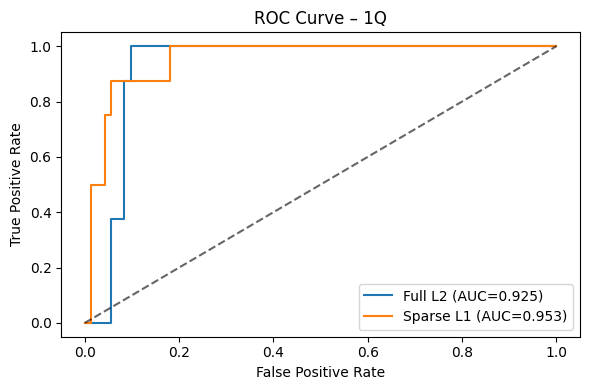

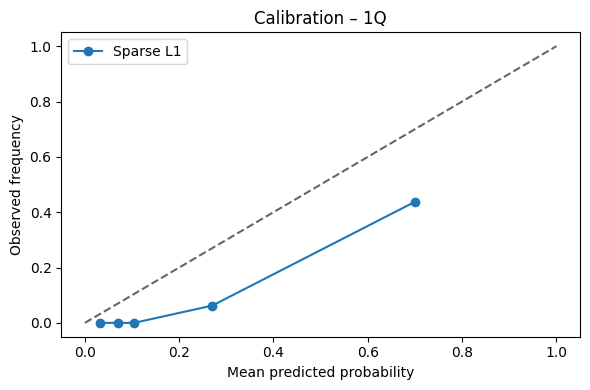

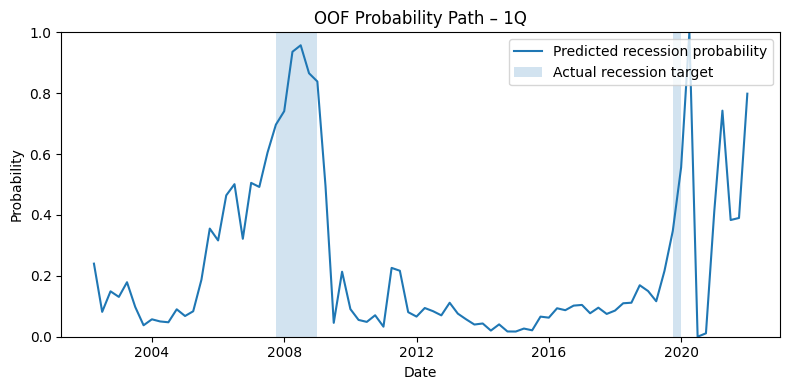

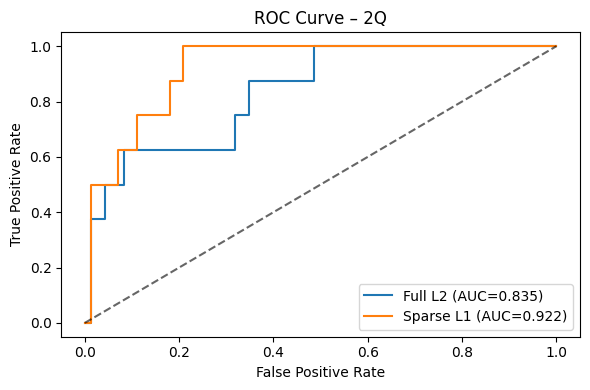

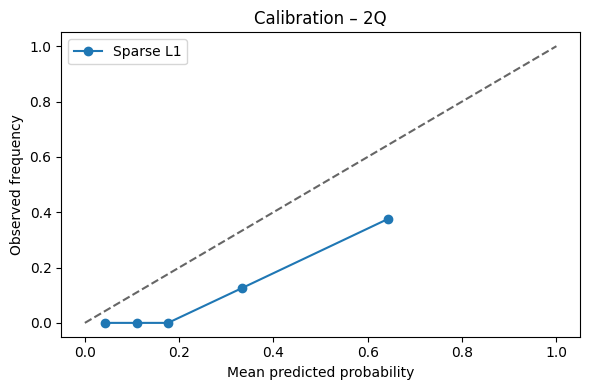

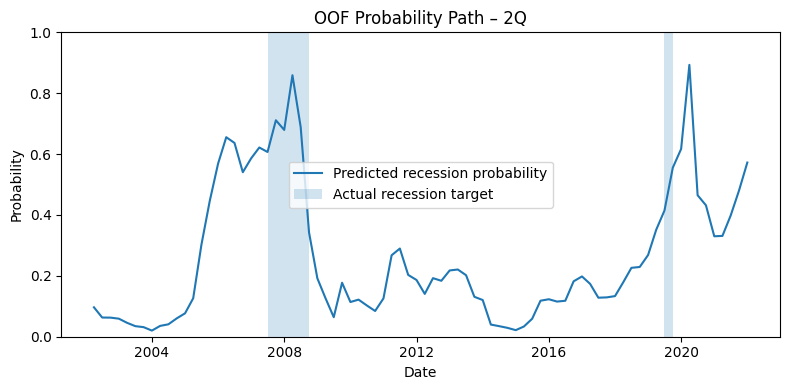

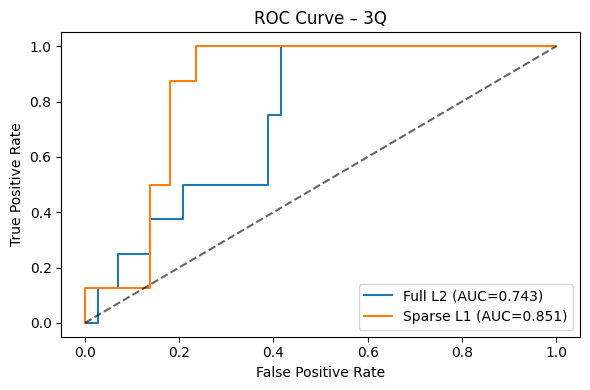

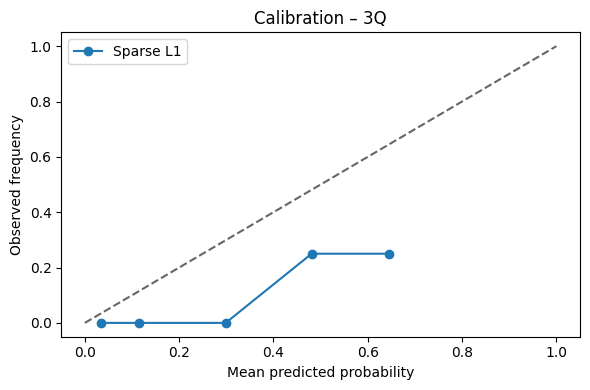

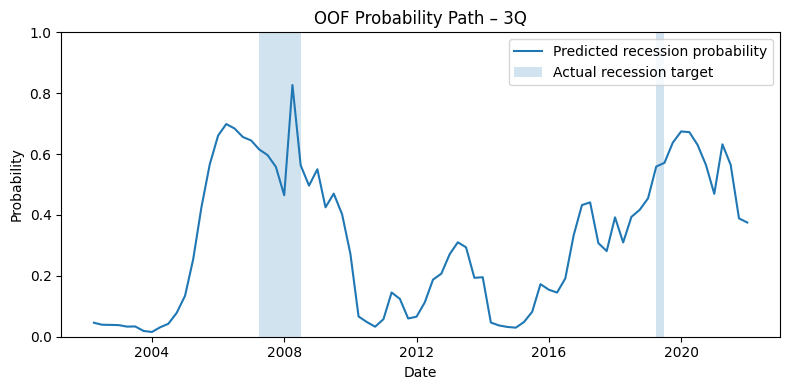

In [24]:
# c
for horizon in horizons:
    sparse = oof_store[(horizon, "sparse_l1")]
    full = oof_store[(horizon, "full_l2")]

    # ROC
    plt.figure(figsize=(6, 4))
    for name, frame in [("Full L2", full), ("Sparse L1", sparse)]:
        fpr, tpr, _ = roc_curve(frame["y_true"], frame["y_prob"])
        auc = roc_auc_score(frame["y_true"], frame["y_prob"])
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {horizon.replace('Target_', '').replace('_ahead', '')}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"{horizon}_roc.png"), dpi=150)
    plt.show()

    # Calibration
    prob_true, prob_pred = calibration_curve(sparse["y_true"], sparse["y_prob"], n_bins=5, strategy="quantile")
    plt.figure(figsize=(6, 4))
    plt.plot(prob_pred, prob_true, marker="o", label="Sparse L1")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed frequency")
    plt.title(f"Calibration – {horizon.replace('Target_', '').replace('_ahead', '')}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"{horizon}_calibration.png"), dpi=150)
    plt.show()

    # Predicted probability path
    plt.figure(figsize=(8, 4))
    plt.plot(sparse["Date"], sparse["y_prob"], label="Predicted recession probability")
    plt.fill_between(
        sparse["Date"], 0, 1,
        where=sparse["y_true"].astype(bool),
        alpha=0.2,
        transform=plt.gca().get_xaxis_transform(),
        label="Actual recession target"
    )
    plt.ylim(0, 1)
    plt.xlabel("Date")
    plt.ylabel("Probability")
    plt.title(f"OOF Probability Path – {horizon.replace('Target_', '').replace('_ahead', '')}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"{horizon}_probability_timeseries.png"), dpi=150)
    plt.show()


## 3.5 - Mutual Information for Q1, Q2, Q3

In [25]:
# Show MI rankings
for horizon, table in mi_tables.items():
    print("\n", horizon)
    display(table.to_frame("mutual_information"))



 Target_1Q_ahead


,mutual_information
UNRATE_d1,0.127216
FEDFUNDS_d1_roll3,0.124906
UNRATE_d1_roll3,0.108188
UNRATE_d1_roll6,0.102111
T10Y2Y_lag3,0.084538
FEDFUNDS_d1,0.072426
FEDFUNDS_d1_lag1,0.071572
INDPRO_lgyoy_roll6,0.070888
CPIAUCSL_lgyoy_roll6,0.060085
UNRATE_d1_lag1,0.060043



 Target_2Q_ahead


,mutual_information
T10Y2Y_lag3,0.098452
UNRATE_d1_roll3,0.089587
T10Y2Y_lag2,0.084538
CPIAUCSL_lgyoy_roll3,0.075763
UNRATE_d1_lag3,0.075060
FEDFUNDS_d1,0.072573
UNRATE_d1_roll6,0.066670
T10Y2Y_roll6,0.063432
T10Y2Y_roll3,0.062786
INDPRO_lgyoy_roll6,0.058214



 Target_3Q_ahead


,mutual_information
T10Y2Y_lag3,0.148288
T10Y2Y_roll6,0.123234
T10Y2Y_lag2,0.098452
T10Y2Y_lag1,0.084538
UNRATE_d1_lag2,0.084227
UNRATE_d1_roll3,0.080965
BAA10Y_roll6,0.078928
T10Y2Y_roll3,0.069323
UNRATE_d1_roll6,0.062233
CPIAUCSL_lgyoy_roll3,0.060241


In [26]:
# Show coefficient tables
for horizon, table in coef_tables.items():
    print("\n", horizon)
    display(table.head(10))



 Target_1Q_ahead


,feature,coef,p_value,odds_ratio,ci_low,ci_high
0,const,-19.255922,0.041389,4.337696e-09,3.991160e-17,4.714321e-01
3,CPIAUCSL_lgyoy,3.684554,0.045584,3.982736e+01,1.075041e+00,1.475496e+03
9,FEDFUNDS_d1_lag3,-2.872365,0.074736,5.656501e-02,2.402017e-03,1.332047e+00
1,BAA10Y,5.913129,0.094252,3.698615e+02,3.632478e-01,3.765956e+05
11,post_2008,3.671164,0.100019,3.929761e+01,4.948306e-01,3.120871e+03
2,INDPRO_lgyoy,2.420419,0.138004,1.125057e+01,4.593748e-01,2.755383e+02
4,FEDFUNDS_d1,-2.138749,0.331285,1.178021e-01,1.575049e-03,8.810735e+00
8,FEDFUNDS_d1_lag1,-1.913428,0.353173,1.475737e-01,2.598869e-03,8.379793e+00
7,T10Y2Y_roll6,-13.232913,0.367383,1.790683e-06,5.712716e-19,5.612999e+06
10,FEDFUNDS_d1_roll3,0.759699,0.824880,2.137632e+00,2.555644e-03,1.787991e+03



 Target_2Q_ahead


,feature,coef,p_value,odds_ratio,ci_low,ci_high
2,CPIAUCSL_lgyoy,2.853638,0.058886,1.735078e+01,8.984000e-01,3.350954e+02
8,post_2008,6.993726,0.076408,1.089774e+03,4.760649e-01,2.494635e+06
5,T10Y2Y_roll6,-28.429147,0.125693,4.501717e-13,7.089453e-29,2.858536e+03
1,BAA10Y,2.636213,0.143656,1.396024e+01,4.077264e-01,4.779877e+02
3,FEDFUNDS_d1,-4.237771,0.219841,1.443974e-02,1.658028e-05,1.257555e+01
6,FEDFUNDS_d1_lag2,-5.207952,0.253762,5.472870e-03,7.143230e-07,4.193104e+01
7,FEDFUNDS_d1_roll3,3.230207,0.600103,2.528490e+01,1.439287e-04,4.441966e+06
4,T10Y2Y_lag3,2.891698,0.783154,1.802389e+01,2.051743e-08,1.583339e+10
0,const,-32.075345,0.993511,1.174504e-14,0.000000e+00,inf
9,post_2020,-9.504799,0.999496,7.449346e-05,0.000000e+00,inf



 Target_3Q_ahead


,feature,coef,p_value,odds_ratio,ci_low,ci_high
3,T10Y2Y_lag3,-5.668942,0.001113,0.003452,0.000114,0.104250
4,post_2008,1.915422,0.007682,6.789805,1.660504,27.763532
2,CPIAUCSL_lgyoy,0.892531,0.060371,2.441301,0.961832,6.196457
1,BAA10Y,0.356484,0.594475,1.428299,0.384442,5.306490
0,const,-8.515751,0.999158,0.000200,0.000000,inf
5,post_2020,-6.362078,0.999835,0.001726,0.000000,inf


## Notes for the report

- The **walk-forward evaluation** is the out-of-sample score you should report first.
- The **sparse L1 model** is usually the cleaner baseline for interpretation.
- The coefficient significance table is **descriptive**, because it is fit on the full sample after feature screening.
- For the presentation, the cleanest story is:
  - **1Q ahead** should perform best
  - **2Q ahead** should still be useful but weaker
  - **3Q ahead** should degrade as expected
  - yield-curve and financial-stress variables should dominate the leading signal
